# Chapter 6 | Ensemble Methods

## Table of Contents
1. [Introduction](#1.-introduction)
2. [Voting Classifier](#2.-voting-classifier)
3. [Bagging and Pasting](#3.-bagging-and-pasting)
   - [Out-of-Bag Evaluation](#out-of-bag-evaluation)
   - [Random Patches and Random Subspaces](#random-patches-and-random-subspaces-sampling-features-andor-instances)
   - [Random Forests](#random-forests)
4. [Boosting](#4-boosting)
5. [Stacking](#5-stacking)

## 1. Introduction
An **Ensemble** is defined as a **group of predictors**. The idea is that aggregating the predictions of a group of predictors, we'll often get a better predictions that with the best individual predictor (similarly to asking to random people a question and then aggregating the answers will take to a better answer).

One of the most used Ensemble Algorithms is **Random Forest**, which is an ensemble of decision trees; despite the simplicity, it's one of the most powerful ML algorithms today.

## 2. Voting Classifier
It's an **Ensemble Method** for classification; we have 2 main type of **Voting Classifier**:
- **Hard Voting Classifier**: aggregate the predictions of different classifiers by assigning the class with most votes;
- **Soft Voting Classifier**: aggregate the predictions of different classifiers by assigning the highest average class probability (this requires all classifiers to be able to estimate class probabilities).

(Soft Voting usually takes to better results, but it is not always usable due to the need for class probabilities)

These 2 simple methods already take to improve the accuracy classifier by aggregating them, even if they are weak classifiers (provided there are sufficient number of classifiers and that they are sufficiently diverse each other); to better understand this, let's try with an analogy:

suppose to have a biased coin with 51% chance of heads and 49% of tails (this is our weak binary classifier with 51% accuracy); tossing it 1000 times (having 1000 different weak classifiers) takes to around 75% heads (accuracy around 75%); tossing it 10000 times takes to around 97% accuracy!

This is due to the **Law of Large Numbers**:

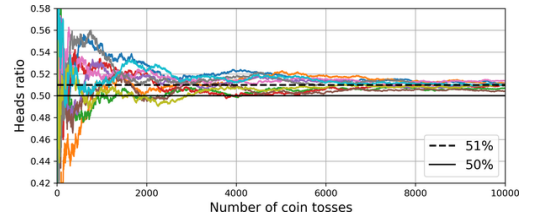

Of course, classifiers are not exactly like coin flips, because they are not perfectly independent each other (they are trained on the same data), but the more diverse they are, the more chance they will make different types of error there is, so the more the ensemble will be useful.

We can implement a voting classifier with the class `VotingClassifier` by Scikit-Learn (this will be an Hard Voting Classifier by default, but can become a Soft one if we set the hyperparameter `voting="soft"`, and if all classifiers can estimate class probabilities):

In [1]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(random_state=42))
    ]
)
voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


Let's first see the individual classifier's accuracy (on test set):

In [2]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, '=', clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


We can make predictions with the Hard Voting Classifier with the `predict()` method:

In [3]:
voting_clf.predict(X_test[:1])

array([1])

Let's now look at the Hard Voting Classifier performance:

In [4]:
voting_clf.score(X_test, y_test)

0.912

It outperforms the individual ones!

Let's now fit a Soft Voting Classifier (to do so, we need all our classifiers to estimate class probabilities, which doesn't happen to be the case for `SVC`; but as we know, in `SVC` we can put `probability=True` to allow SVC to use CV to estimate class probabilities):

In [5]:
voting_clf.voting = 'soft'
voting_clf.named_estimators['svc'].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.92

Even better!

## 3. Bagging and Pasting

While with Voting Classifier the idea was to use very different training algorithms, **Bagging** and **Boosting** are 2 approaches both involving using as predictors the same algorithm, but trained on different random subsets of the training set:
- **Bagging**: the random sampling is performed **with Replacement** (bagging is short for "bootstrap aggregating");
- **Pasting**: the random sampling is performed **without Replacement**.

Once all predictors are trained, the predictions are aggregated by an aggregating function: in classification soft voting is performed whenever is possible, otherwise hard voting; in regression average is typically performed.

In Scikit-Learn, we got the classes `BaggingClassifier` and `BaggingRegressor`; by default the hyperparameter `bootstrap` is set to `True`, so they perform Bagging (set it to `False` to perform Pasting); another useful parameter is `n_jobs`, which tells the number of CPU cores to use for training and predictions (if set to `-1` means to use all available cores).

In [6]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), 
    n_estimators=500,
    max_samples=100,
    n_jobs=-1,
    random_state=42
)

bag_clf.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,500
,max_samples,100
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


Below a comparison of the Decision Boundaries of 1 decision tree (left) and the above Bagging Classifier:

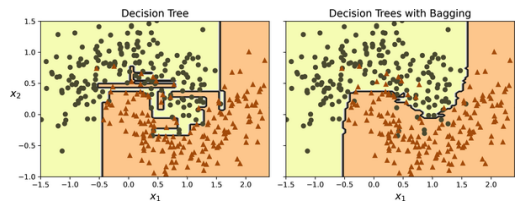

As we can see, ensemble's prediction will likely generalize better (similar bias, but smaller variance).

Talking about which is better between Bagging and Pasting, Bagging usually takes to higher bias (more diversity in the subsets on which each predictor is trained on), which takes to extra diversity and less correlation between predictors, which generally takes to lower variance (and better performance). Given that, Bagging is generally preferred to Pasting.

### Out-of-Bag Evaluation

When training a `BaggingClassifier` with replacement (Bagging), it can be shown matematically that only abouy 63% of training instances are sampled on average for each predictor; the remaining 37% training instances are called **Out-of-Bag (OOB)** instances (note how they are not the same 37% for all predictors).

One smart thing we can do is use these OOB instances to evaluate the bagging ensemble, without the need for a separate validation set. This can be done in Scikit-Learn by putting `oob_score=True` in `BaggingClassifier`:

In [7]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, oob_score=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_


0.896

The OOB evaluation is estimating an ccuracy of 89.6% on the test set; let's check:

In [8]:
from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

The OOB evaluation was a bit pessimistic in this case, but it is quite accurate.

We can also access the OOB decision function for each training instances (given that the individual classifier can estimate class probabilities):

In [9]:
bag_clf.oob_decision_function_[:3].round(3)

array([[0.324, 0.676],
       [0.338, 0.662],
       [1.   , 0.   ]])

First observation has 32.4% of belonging to Negative Class, 67.6% of belonging to Positive Class, and so on.

### Random Patches and Random Subspaces (Sampling Features and/or Instances)
The `BaggingClassifier` supports **sampling features** aswell; this can be controlled by the 2 hyperparameters `max_features` and `bootstrap_features`, which work the same way as `max_samples` and `bootstrap`, but for features instead of instances. This is particularly useful with high-dimensional inputs (e.g., images) to speed up training.

We can distinguish between 2 methods:
- **Random Patches Method**: **sampling both training instances and features**;
- **Random Subspaces Method**: **keeping all instances** (`bootstrap=False` and `max_samples=1.0`) but **sampling features** (`bootstrap_features=True` and/or `max_features` smaller than 1.0)

Sampling features takes bit more bias for lower variance.

### Random Forests
A **Random Forest** is an ensemble of decision trees, typically trained via bagging and with `max_samples` set to size of training set.

Instead of passing a `DecisionTreeClassifier` to a `BaggingClassifier`, we have the `RandomForestClassifier` class (and `RandomForestRegressor` for regression):

In [10]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)

y_pred = rnd_clf.predict(X_test)

This classes have very similar hypeparameters to the Decision Tree ones, plus all the hyperparameters of the Bagging ones. They also introduce some randomness by selecting the best feature on which to split just on a sub-sample of features (by default on a $\sqrt n$ of features over the $n$ total), introducing greater diversity and trading again an higher bias for a lower variance, generally yielding a better model.

We could get the same classifier with `BaggingClassifier`:

In [11]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500, n_jobs=-1, random_state=42)

#### Extremely Randomized Trees (or Extra-Trees)
As we said, at each node, Random Forests select the best feature on which to split among $\sqrt n$ sampled features. We can increase this randomness using a random threshold for each feature (instead of searching for the best threshold as a Decision Tree would do) obtaining a so called **Extremely Randomized Tree** (or **Extra-Tree**). These furtherly trade more bias for lower variance and are also much faster to train (finding the best possible threshold is very time-consuming).

We can obtain one by setting `splitter="random"` in a `RandomForestClassifier` (or `RandomForestRegressor`), or by using the dedicated class `ExtraTreesClassifier` (or `ExtraTreesRegressor`) (notice how the Extra Trees versions are identical to the original Random Forest, except that by default `bootstrap` is set to `False`).

Just as Decision Tree classes, both Random Forest and Extra-Trees classes support missing values natively (i.e., no need for an imputer).

#### Feature Importance
Random Forests allows for measuring the relative importance of each feature, intended as the weighted average across all trees of how much that feature reduces impurity. 

Scikit-Learn computes this score for each feature and scales it so that the sum of all importances is 1. These scores are in the `feature_importances_` variable:

In [12]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(X, y)
for score, name in zip(rnd_clf.feature_importances_, X.columns):
    print(f"{name}: {score:.2f}")

sepal length (cm): 0.11
sepal width (cm): 0.02
petal length (cm): 0.44
petal width (cm): 0.42


A cool thing is to do so for the MNIST handwritten dataset (or any other image-related task) to obtain an importance score for each pixel and then plot that as an image.

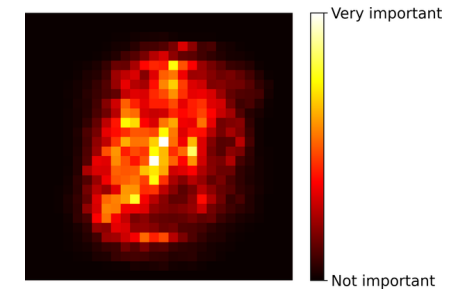
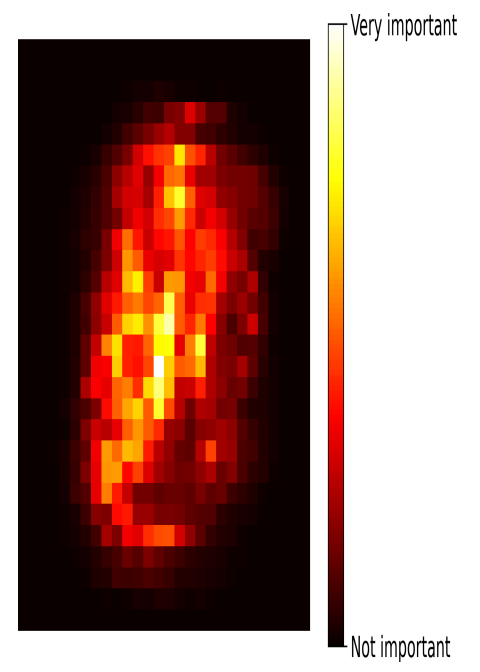

## 4. Boosting
It refers to an ensemble emthod combining several weak lerners into a strong lerner. The idea is to train predictors sequentially, each trying to correct its predecessor. 

The most popular boosting method are **AdaBoost** (short for **Adaptive Boosting**) and **Gradient Boosting**:

### AdaBoost
It involves forcing a predictor to pay more attention to the training instances that its predecessor underfitted, in order to obtain a predictor that focuses more on the hard cases.

For example, an **AdaBoost classifier** trains a base classifier (e.g., Decision Tree), uses it to make predictions on the training set, then increases the relative weight of misclassified instances; it then trains a second classifier, using these update weights and so on.

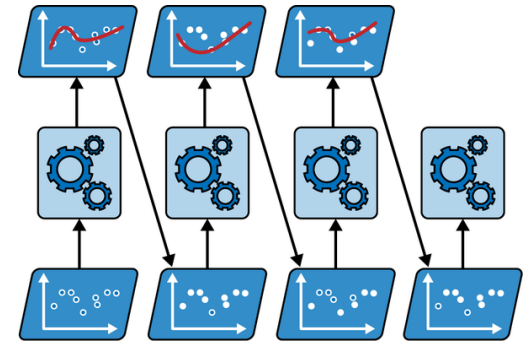

Considering that each predictor must wait for the previous one to finish training, this technique cannot be parallelized and doesn't scale as well as bagging/pasting.

Let's look closely how this algorithm works:

0. At the beginning, each instance weight $w^{(i)}$ is set to $1/m$; 
1. Predictor is trained and its weighted error rate $r_j$ is computed:$$r_j = \sum_{i = 1, \hat y_j^{(i)} \ne y^{(i)}}^m w^{(i)} \space \space \space \text{where } \hat y_j^{(i)} \text{is the } j^{th} \text{ prediction for the } i^{th} \text{ instance} $$
2. The predictor's weight $\alpha_j$ is then computed based on the rate $r_i$ and learning rate $\eta$ (default is 1): $$\alpha_j = \eta \log \frac{1-r_j}{r_j}$$ The more accurate the predictor is, the lower the rate $r_j$ is, the higher its weight $\alpha_j$ will be;
3. The instance weights are updated: $$\text{for } i = 1, 2, ..., m$$ $$w^{(i)} ← \begin{Bmatrix} w^{(i)} & \text{if } \hat y_j^{(i)} = y^{(i)} \\ w^{(i)} \exp(\alpha_j) & \text{if } \hat y_j^{(i)} \ne y^{(i)} \end{Bmatrix}$$ 
4. The instance weights are normalized (i.e., divided by $\sum_{i = 1}^m w^{(i)}$)
5. Repeat from step 1 until desired number of predictors is reached, or perfect predictor is found.

The predictions are then easily computed with the formula:
$$\hat y(x) = \argmax_k \sum_{j = 1, \hat y_j (x) = k}^N \alpha_j \space \space \space \text{where } N \text{ is the number of predictors}$$

Scikit-Learn uses **SAMME (Stagewise Additive Modeling using a Multiclass Exponential Loss Function)**, which is a multiclass version of AdaBoost. When there are 2 classes, SAMME is equivalent to AdaBoost. If the predictors can estimate class probabilities, Scikit-Learn allows for a variant claled `SAMME.R` (where *R* stands for "Real") which relies on class probabilities and generally performs better.

Let's train an `AdaBoostClassifier` with 30 **Decision Stumps** (i.e., a decision tree with `max_depth = 1`, so composed of a single decision node taking to two leaf nodes):

In [13]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=30, learning_rate=0.5, random_state=42
)

ada_clf.fit(X_train, y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,30
,learning_rate,0.5
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


### Gradient Boosting
Just as AdaBoost, **Gradient Boosting** works by sequentially adding predictors to an ensemble but, instead of tweaking the instance weights at each iteration like AdaBoost does, it fits the new predictor to the **residual errors** made by the previous predictor. 

Let's see a regression example using decision trees as predictors (in this special case, the algorithm is called **Gradient Tree Boosting**, or **Gradient Boosted Regression Trees (GBRT)**).

First, we generate some noisy quadratic data (more precisely $y = 3 X^2 + GaussianNoise$):

In [14]:
import numpy as np

np.random.seed(42)

X = np.random.rand(100, 1) * 0.5
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100)

Let's then fit the first `DecisionTreeRegressor`:

In [15]:
from sklearn.tree import DecisionTreeRegressor

tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


We then train a second regressor on the residuals made by the first, and a third regressor on the reisdual made by the second:

In [16]:
y2 = y-tree_reg1.predict(X)

tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg2.fit(X, y2)

y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg3.fit(X, y3)

,criterion,'squared_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


We obtained an ensemble! We can now use this to make predictions on a new instance by summing up the predictions of all the trees:

In [17]:
X_new = np.array([[-0.4], [0.], [0.5]])
sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

array([0.02263712, 0.02263712, 0.76863767])

Of course, we have the dedicated class `GradientBoostingRegressor` to train a GBRT (and `GradientBoostingClassifier` for classification); it has hyperparameters to control growth of decision trees (e.g., `max_depth`, `min_samples_leaf`), and to control the ensemble, such as the number of trees (`n_estimators`):

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0, random_state=42)
gbrt.fit(X, y)

,loss,'squared_error'
,learning_rate,1.0
,n_estimators,3
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


Below the graphical representation (on left, the 3 trees' predictions, on right the ensemble's prediction):

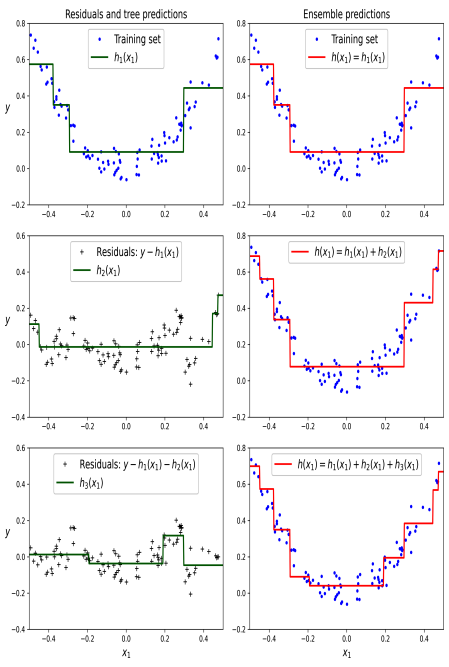

We also have the `learning_rate` hyperparameter which scales the contribution of each tree: lower values, such as 0.05, means we would need more trees to fit the training set, but it will usually generalize better (this is called **Shrinkage** and it is a Regularization Technique).

On left, a case with not enough trees to fit the training set, on right the right amount:

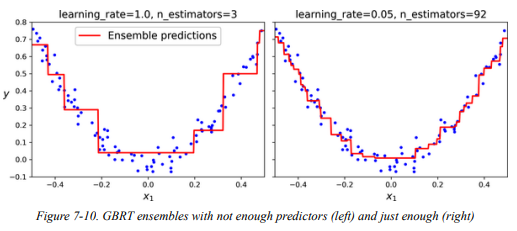

To find the optimal number of trees, we could use `GridSearchCV` or `RandomizedSearchCV`, but we can also set the hyperparameter `n_iter_no_change` to an integer value (e.g., 10) to perform early stopping and stop adding trees during training if last 10 trees didn't help (if too low, training may stop too early and model may underfit; if too high, it may overfit). This hyperparameter automatically splits the training set into a smaller training set and a validation set, for which the proportion is controlled by another hyperparameter `validation_fraction` (default is 0.01); we can also control the `tol` hypeparameters wich determines the maximum performance improvement counting as accettable (default is 0.0001).

Let's fit an early stopping: 

In [21]:
gbrt_best = GradientBoostingRegressor(max_depth=2, learning_rate = 0.05, n_estimators=500, n_iter_no_change=10, random_state=42)
gbrt_best.fit(X, y)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [23]:
gbrt_best.n_estimators_

55

The class also supports a `subsample` hyperparameter allowing to specify a fraction of training instances with which to train each tree: this trades higher bias for lower variance and speeds up training considerably (this is called **Stochastic Gradient Boosting**).

#### Histogram-Based Gradient Boosting
The **Histogram-Based Gradient Boosting (HGB)** is a GBRT implementation optimized for large datasets: it works by **binning** the input features, replacing them with integers (`max_bins` controls the number of bins and it's default to 255, which is the maximum possible value). 

Binning reduces the number of possible thresholds to evaluate and allows for faster and more memory-efficient data structures; moreover, the way binning is performed removes the need for sorting the features at each tree training: all of this takes the complexity of GBRT from $O(n\times m \times \log(m))$ to $O(b \times m)$, with $n$ features, $m$ training instances and $b$ bins (basically with large datasets HGB traing hundreds of times faster than regula GBRT). Of course, this binning causes a precision loss (it is basically a regularizer, which may take to underfit or overfit).

We can implement one with the classes `HistGradientBoostingRegressor` and `HistGradientBoostingClassifier`; they are similar to the respective Gradient Boosting classes, but with some differences:
- early stopping is automatically performed is number of instances is greater than 10,000 (we still have the `early_stopping` hyperparameter that can be set to `True` or `False` if needed);
- subsampling is not supported;
- `n_estimators` is renamed to `max_iter`;
- the only decision tree hyperparameters we have are `max_leaf_nodes`, `min_samples_leaf`, `max_depth` and `max_features`.

They also support missing values natively; moreover, categorical features must be represented as integers ranging from 0 to a number lower than `max_bins` (you can use `OrdinalEncoder` to do so).

Let's train an HGB on California Housing Dataset; first, let's load it:

In [29]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

housing_labels = housing["median_house_value"]
housing = housing.drop("median_house_value", axis=1)

And then train the model:

In [30]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

hgb_reg = make_pipeline(
    make_column_transformer(
        (OrdinalEncoder(), ["ocean_proximity"]),
        remainder="passthrough",
        force_int_remainder_cols = False),
    HistGradientBoostingRegressor(categorical_features= [0], random_state=42)
)
hgb_reg.fit(housing, housing_labels)

/home/essskevin/projects/hands_on_ml/venv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('columntransformer', ...), ('histgradientboostingregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ordinalencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Without hyperparameter tuning, this model yields a 47,600 RMSE, which is not too bad.

### Other Gradient Boosting Implementations
In Python, we have other available gradient boosting, particularly **XGBoost**, **CatBoost** and **LightGBM**, which have very similar APIs to Scikit-Learn's one. Most of these allows for hardware acceleration using GPUs.

## 5. Stacking
**Stacking** (short for **Stacked Generalization**) is another ensemble method in which instead of using functions to aggregate the predictions of all the predictors in the ensemble (such as hard voting for example), they are aggregated using another final predictor (called **Blender**, or **Meta Learner**), which takes those predictions as inputs and yields the final prediction as output.

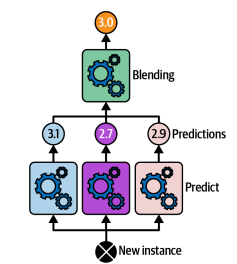

To do so, we first need to build the **Blending Training Set**, for example by calling `cross_val_predict()` on every predictor in the ensemble and use these as input features of the Blender (target can simply be copied from the original train set): this takes to obtain one input feature per predictor. We can then train the blender on this new Blending Training Set.

Once this is done, the base predictors must be retrained one last time on full original training set (since `cross_val_predict()` doesn't allow to access the estimators).

By doing so, we could fit several different Blenders (using different final predictors) and put a final Blender after these Blenders, and so on (this increase training time and system complexity, but generally squeezes out a better performance).

We can implement one with the classes `StackingClassifier` and `StackingRegressor`; let's implement one classifier on the moon dataset:

In [31]:
from sklearn.ensemble import StackingClassifier

stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(probability=True, random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=43),
    cv = 5
)
stacking_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,final_estimator,RandomForestC...ndom_state=43)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


For each predictor, it will try to call `predict_proba()` (if not available, `decision_function()` or, as last resort, `predict()`).

If no final estimator is specified, `StackingClassifier` will use `LogisticRegression`, while `StackingRegressor` will use `RidgeCV`.

While the soft voting classifier on moon got a 92% accuracy on test set, this would get a 92.8%.

## 6. Ensemble Methods Summary

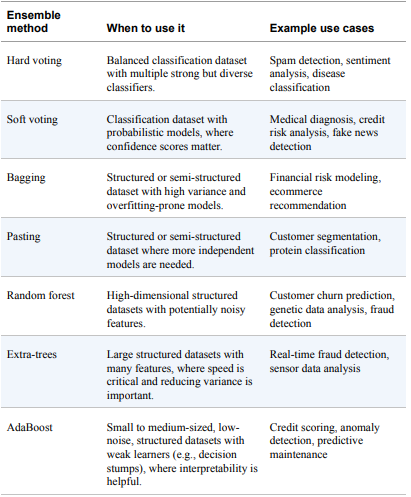

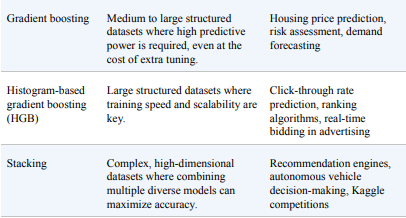

When first starting a ML task, Random Forests, AdaBoost, GBRT and HGB are among the first models you should test, considering they require little preprocessing and are good for getting a prototype.